plot kappa

\n\n=== Isolating the Perceptual Effect of Rate ===
Trial 0/1000...
Trial 100/1000...
Trial 200/1000...
Trial 300/1000...
Trial 400/1000...
Trial 500/1000...
Trial 600/1000...
Trial 700/1000...
Trial 800/1000...
Trial 900/1000...
\nPERCEPTION at SLOW r=1.0 (N=968) top 8:
  ['lei', 'sure', 'or', 'time']            |  468 |  48.3%
  ['lei', 'sure', 'time']                  |  359 |  37.1%
  ['lei', 'or', 'time']                    |   17 |   1.8%
  ['lei', 'sure', 'lei', 'sure', 'or', 'time'] |   15 |   1.5%
  ['lei', 'sure']                          |   14 |   1.4%
  ['lei', 'time']                          |   10 |   1.0%
  ['lei', 'sure', 'lei', 'sure', 'time']   |    9 |   0.9%
  ['sure', 'or', 'time']                   |    8 |   0.8%
  -> 'or' present: 562/968 = 58.1%
\nPERCEPTION at FAST r=2.0 (N=968) top 8:
  ['lei', 'sure', 'or', 'time']            |  468 |  48.3%
  ['lei', 'sure', 'time']                  |  359 |  37.1%
  ['lei', 'or', 'time']                    |   17 |   1.8

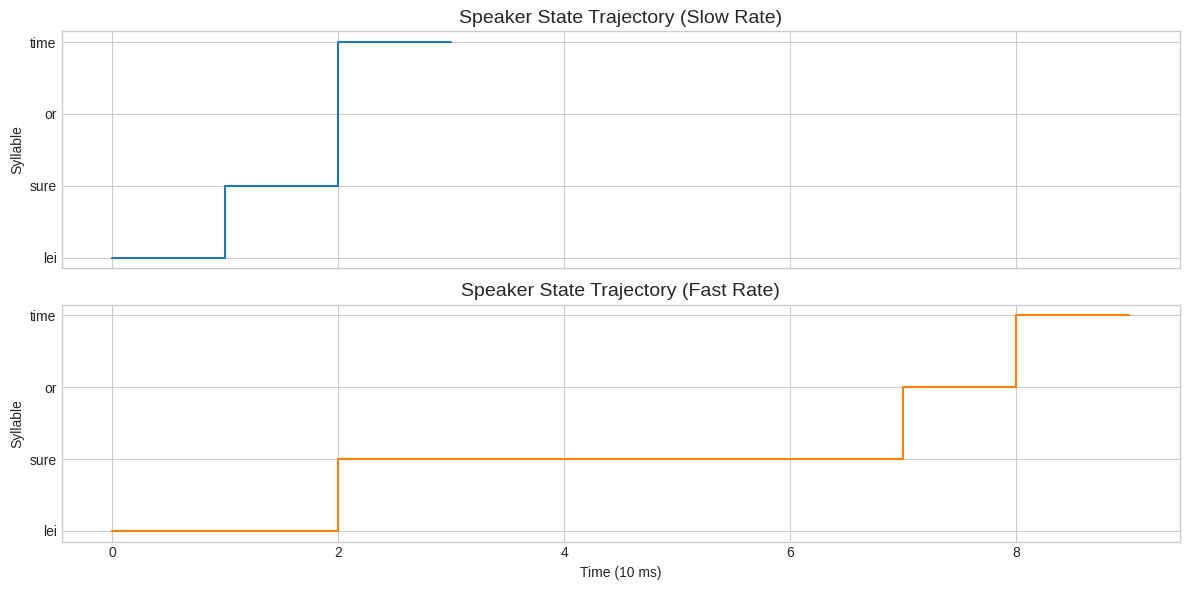

\n\n=== Generating Plot for Viterbi Paths ===


/tmp/ipython-input-1724103956.py:339: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


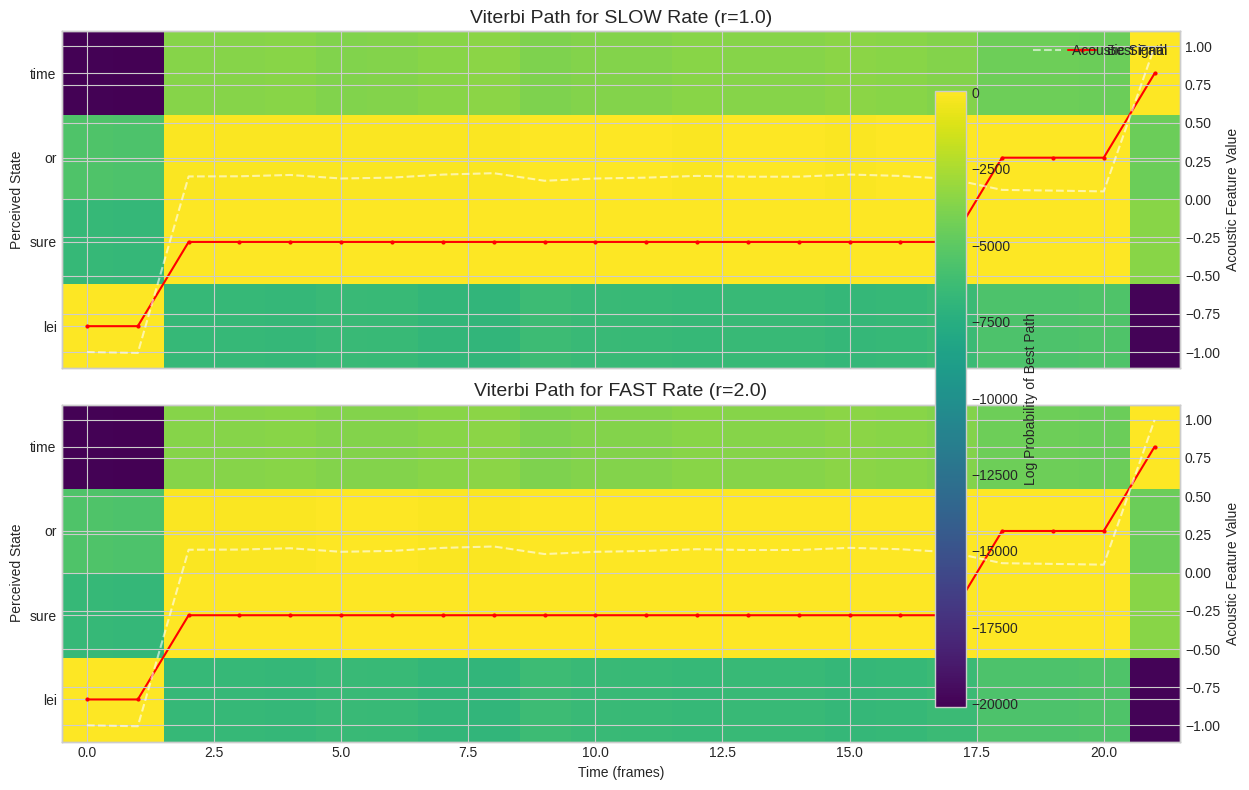

In [ ]:
import numpy as np
from collections import Counter
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(7)

# --------------
# States & Durations setup
# --------------
STATES = ["START", "lei", "sure", "or", "time", "STOP"]
EMIT_STATES = ["lei", "sure", "or", "time"]
i = {s: k for k, s in enumerate(STATES)}

# Base durations in frames (e.g., 10 frames = 100ms)
BASE_DURATIONS = {
    "lei":  20,
    "sure": 20,
    "or":   10,
    "time": 20
}

# ----------------
# Emissions setup
# ----------------
mu = {
    "lei":  -1.0,
    "sure":  0.15,
    "or":    0.05,
    "time":  1.0
}
sigma = {s: 0.01 for s in EMIT_STATES}

# ------------------------
# Base transitions (pi_bar)
# ------------------------
def make_pi_bar(uniform_eps=0.0):
    n = len(STATES)
    T = np.zeros((n, n))
    def row_with_primary(from_s, primary):
        row = np.zeros(n)
        used = 0.0
        for to_s, w in primary.items():
            row[i[to_s]] += w
            used += w
        leftover = max(0.0, 1.0 - used)
        mask = np.ones(n, dtype=bool)
        for to_s in primary.keys():
            mask[i[to_s]] = False
        mask[i["START"]] = False
        if from_s == "STOP":
            mask[:] = False
            mask[i["STOP"]] = True
        count = mask.sum()
        if count > 0 and leftover > 0:
            row[mask] += leftover / count
        if uniform_eps > 0:
            row += uniform_eps
        row = row / row.sum()
        return row

    T[i["START"]] = row_with_primary("START", {"lei": 0.97})
    T[i["lei"]]   = row_with_primary("lei",   {"sure": 0.94})
    T[i["sure"]]  = row_with_primary("sure",  {"or": 0.55, "time": 0.40})
    T[i["or"]]    = row_with_primary("or",    {"time": 0.95})
    T[i["time"]]  = row_with_primary("time",  {"STOP": 0.96})
    T[i["STOP"]]  = row_with_primary("STOP",  {"STOP": 1.0})
    return T

pi_bar = make_pi_bar(uniform_eps=0.0)

# ------------------------
# Stickiness mapping kappa(gamma, rate)
# ------------------------
def kappa_from_gamma_rate(gamma_val, rate, base=1.2, clip=(0.55, 0.93)):
    val = 1.0 - np.exp(-base * (gamma_val + 0.25) / (rate + 1e-9))
    return float(np.clip(val, clip[0], clip[1]))

def sample_gammas(seed=None):
    rng = np.random.default_rng(seed)
    g = {}
    for s in STATES:
        if s in {"START", "STOP"}: g[s] = 0.0
        else: g[s] = rng.gamma(shape=2.0, scale=1/5.0)
    return g

# revise
# start with static T
def build_T(rate, gammas):
    n = len(STATES)
    T = np.zeros((n, n))
    for s_from in STATES:
        row = pi_bar[i[s_from]].copy()
        if s_from in {"START", "STOP"}:
            T[i[s_from]] = row
        else:
            kappa = kappa_from_gamma_rate(gammas[s_from], rate)
            row = (1 - kappa) * row
            row[i[s_from]] += kappa
            T[i[s_from]] = row / row.sum()
    return T

# ------------------------
# Generative process (Speaker)
#
# ------------------------
def simulate_one(rate, gammas, max_frames=1000, rng=None):
    if rng is None: rng = np.random.default_rng()
    T = build_T(rate, gammas)
    s = "START"
    states,emissions = [], []
    frame = 0
    while frame < max_frames:
        s = rng.choice(STATES, p=T[i[s]])
        if s == "STOP": break
        states.append(s)
        if s in EMIT_STATES:
            emissions.append(rng.normal(loc=mu[s], scale=sigma[s]))
        frame += 1
    return states, np.array(emissions).reshape(-1, 1)

# ------------------------
# Decoding process (Listener)
# ------------------------
def sigmoid_kappa(t_elapsed, duration, steepness=0.5):
    """
    Calculates stickiness (kappa) using a decaying sigmoid function.
    """
    val = 1 / (1 + np.exp(steepness * (t_elapsed - duration)))
    return val

def get_dynamic_logT(rate, gammas, dwell_times):
    """
    Computes the log transition matrix for the current time step using the new sigmoid kappa.
    """
    n = len(STATES)
    logT = np.full((n, n), -np.inf)
    for s_from_idx in range(n):
        s_from = STATES[s_from_idx]
        row = pi_bar[s_from_idx].copy()
        if s_from in {"START", "STOP"}:
            logT[s_from_idx, :] = np.log(row + 1e-12)
        else:
            t_elapsed = dwell_times[s_from_idx]
            effective_duration = BASE_DURATIONS[s_from] / rate
            kappa_t = sigmoid_kappa(t_elapsed, effective_duration)
            row = (1 - kappa_t) * row
            row[s_from_idx] += kappa_t
            logT[s_from_idx, :] = np.log(row / row.sum() + 1e-12)
    return logT

def viterbi_decode_dynamic(a_data, rate, gammas):
    T_len = len(a_data)
    n = len(STATES)
    V = np.full((T_len, n), -np.inf)
    B = np.zeros((T_len, n), dtype=int)
    D = np.zeros((T_len, n), dtype=int)
    logE = emission_log_probs(a_data)
    start_row = np.log(pi_bar[i["START"]] + 1e-12)
    for s_idx in range(n):
        if STATES[s_idx] in EMIT_STATES:
            V[0, s_idx] = start_row[s_idx] + logE[0, s_idx]
            D[0, s_idx] = 1
    for t in range(1, T_len):
        logT_t = get_dynamic_logT(rate, gammas, D[t-1])
        for j in range(n):
            prev_path_probs = V[t-1, :] + logT_t[:, j]
            best_prev_k = np.argmax(prev_path_probs)
            V[t, j] = prev_path_probs[best_prev_k] + logE[t, j]
            B[t, j] = best_prev_k
            if j == best_prev_k:
                D[t, j] = D[t-1, best_prev_k] + 1
            else:
                D[t, j] = 1
    path = np.zeros(T_len, dtype=int)
    path[-1] = np.argmax(V[-1])
    for t in range(T_len - 2, -1, -1):
        path[t] = B[t + 1, path[t + 1]]
    return [STATES[k] for k in path], V, path

# ------------------------
# Helper functions
# ------------------------
def emission_log_probs(a_data):
    T = len(a_data)
    n = len(STATES)
    logp = np.full((T, n), -np.inf)
    for t in range(T):
        for s in EMIT_STATES:
            logp[t, i[s]] = norm.logpdf(a_data[t, 0], loc=mu[s], scale=sigma[s])
    return logp

def compress(seq):
    return [s for idx, s in enumerate(seq) if idx == 0 or s != seq[idx-1]]

def summarize(name, seqs):
    c = Counter(tuple(s) for s in seqs)
    total = sum(c.values())
    print(f"\\n{name} (N={total}) top 8:")
    for (s, cnt) in c.most_common(8):
        print(f"  {list(s)!s:<40} | {cnt:4d} | {100*cnt/total:5.1f}%")
    has_or = sum(1 for s in seqs if "or" in s)
    print(f"  -> 'or' present: {has_or}/{total} = {100*has_or/total:4.1f}%")

# =================================================================
# == EXPERIMENT: ISOLATING THE PERCEPTUAL EFFECT ==
# =================================================================
def run_isolated_perception_experiment(n_trials=1000, rate_slow=1.0, rate_fast=2.0):
    rng = np.random.default_rng(1234)
    gammas = sample_gammas(seed=2025)
    seq_slow_perception = []
    seq_fast_perception = []
    print("\\n\\n=== Isolating the Perceptual Effect of Rate ===")
    for k in range(n_trials):
        if k % 100 == 0: print(f"Trial {k}/{n_trials}...")
        rate_generative = 1.5
        _, ambiguous_acoustic_signal = simulate_one(rate_generative, gammas, rng=rng)
        if len(ambiguous_acoustic_signal) < 3: continue

        # FIX for ValueError is here: Unpack the tuple from viterbi_decode_dynamic
        zhat_slow, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
        seq_slow_perception.append(compress(zhat_slow))

        zhat_fast, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)
        seq_fast_perception.append(compress(zhat_fast))

    summarize(f"PERCEPTION at SLOW r={rate_slow}", seq_slow_perception)
    summarize(f"PERCEPTION at FAST r={rate_fast}", seq_fast_perception)

# =================================================================
# ==  VISUALIZING THE SPEAKER'S STATE TRAJECTORY ==
# =================================================================
def plot_state_trajectory():
    print("\\n\\n=== Generating Plot for State Trajectory ===")
    gammas = sample_gammas(seed=2025)
    rate_slow = 1.0
    rate_fast = 5.0
    slow_states, _ = simulate_one(rate_slow, gammas, max_frames=100)
    fast_states, _ = simulate_one(rate_fast, gammas, max_frames=100)

    y_map = {s: k for k, s in enumerate(EMIT_STATES)}
    slow_y = [y_map[s] for s in slow_states]
    fast_y = [y_map[s] for s in fast_states]

     # --- 2. Define conversion factor and create time axis in ms ---
    FRAME_DURATION_MS = 10  # CHANGED: Define how many ms each frame represents
    slow_x_ms = np.arange(len(slow_y)) * FRAME_DURATION_MS
    fast_x_ms = np.arange(len(fast_y)) * FRAME_DURATION_MS

    # --- 3. Create the Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)
    plt.style.use('seaborn-v0_8-whitegrid')

    ax1.step(np.arange(len(slow_y)), slow_y, where='post', label=f'Slow Rate (r={rate_slow})')
    ax1.set_title('Speaker State Trajectory (Slow Rate)', fontsize=14)
    ax1.set_ylabel('Syllable')
    ax1.grid(True)

    ax2.step(np.arange(len(fast_y)), fast_y, where='post', label=f'Fast Rate (r={rate_fast})', color='C1')
    ax2.set_title('Speaker State Trajectory (Fast Rate)', fontsize=14)
    ax2.set_xlabel('Time (10 ms)')
    ax2.set_ylabel('Syllable')
    ax2.grid(True)

    ax2.set_yticks(list(y_map.values()))
    ax2.set_yticklabels(list(y_map.keys()))

    plt.tight_layout()
    plt.show()

# --- RUN THE SIMULATION & NEW PLOT ---
run_isolated_perception_experiment(n_trials=1000)
plot_state_trajectory()

# =================================================================
# == PLOTTING THE VITERBI PATHS ==
# =================================================================
def plot_viterbi_paths():
    """
    Generates and displays a plot visualizing the Viterbi decoding process
    for a single ambiguous utterance under slow and fast rate conditions.
    """
    print("\\n\\n=== Generating Plot for Viterbi Paths ===")

    # --- 1. Generate one clear example ---
    rng = np.random.default_rng(123) # Use a specific seed for a good example
    gammas = sample_gammas(seed=2025)
    rate_slow = 1.0
    rate_fast = 2.0
    rate_generative = 1.5

    # Keep generating signals until we get one of a reasonable length
    # Using the REVISED simulate_one function
    while True:
        slow_states, ambiguous_acoustic_signal = simulate_one(rate_generative, gammas, rng=rng)
        if 20 < len(ambiguous_acoustic_signal) < 40:
            break

    # --- 2. Decode the signal under both conditions ---
    # We need the V matrix and the integer path for plotting
    _, V_slow, path_slow = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
    _, V_fast, path_fast = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)

    # --- 3. Create the Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    emit_state_indices = [i[s] for s in EMIT_STATES]
    emit_state_names = EMIT_STATES

    # Plot for SLOW rate
    # Heatmap of the Viterbi log-probabilities
    im1 = ax1.imshow(V_slow[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax1.plot(path_slow - 1, 'r-', marker='.', markersize=4, label='Best Path') # Subtract 1 to align with emit_state_indices
    ax1.set_title(f'Viterbi Path for SLOW Rate (r={rate_slow})', fontsize=14)
    ax1.set_yticks(range(len(emit_state_names)))
    ax1.set_yticklabels(emit_state_names)
    ax1.set_ylabel('Perceived State')
    ax1.legend()

    # Overlay the acoustic signal
    ax1_twin = ax1.twinx()
    ax1_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax1_twin.set_ylabel('Acoustic Feature Value')
    ax1_twin.legend(loc='upper right')

    # Plot for FAST rate
    # Heatmap of the Viterbi log-probabilities
    im2 = ax2.imshow(V_fast[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax2.plot(path_fast - 1, 'r-', marker='.', markersize=4, label='Best Path')
    ax2.set_title(f'Viterbi Path for FAST Rate (r={rate_fast})', fontsize=14)
    ax2.set_yticks(range(len(emit_state_names)))
    ax2.set_yticklabels(emit_state_names)
    ax2.set_xlabel('Time (frames)')
    ax2.set_ylabel('Perceived State')

    # Overlay the acoustic signal
    ax2_twin = ax2.twinx()
    ax2_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax2_twin.set_ylabel('Acoustic Feature Value')

    fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', label='Log Probability of Best Path')
    plt.tight_layout()
    plt.show()

# Add this line at the end of your script to run the new plot function
plot_viterbi_paths()